<a href="https://colab.research.google.com/github/ddAdoro/AI-Assignment-SCT314-C004-0594-2026/blob/main/Notebooks/Chap20/20_4_Adversarial_Attacks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 20.4: Adversarial attacks**

This notebook builds uses the network for classification of MNIST from Notebook 10.5.  The code is adapted from https://nextjournal.com/gkoehler/pytorch-mnist, and uses the fast gradient sign attack of [Goodfellow et al. (2015)](https://arxiv.org/abs/1412.6572).  Having trained, the network, we search for adversarial examples -- inputs which look very similar to class A, but are mistakenly classified as class B.  We do this by starting with a correctly classified example and perturbing it according to the gradients of the network so that the output changes.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.


In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import random

In [2]:
# Run this once to load the train and test data straight into a dataloader class
# that will provide the batches
batch_size_train = 64
batch_size_test = 1000
train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/files/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/files/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_test, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.33MB/s]


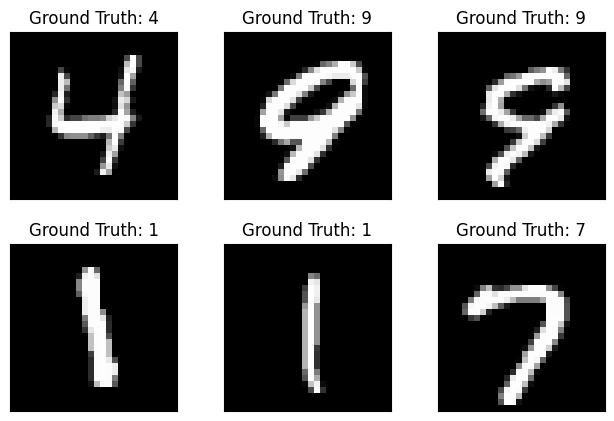

In [3]:
# Let's draw some of the training data
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
plt.show()

Define the network.  This is a more typical way to define a network than the sequential structure.  We define a class for the network, and define the parameters in the constructor.  Then we use a function called forward to actually run the network.  It's easy to see how you might use residual connections in this format.

In [13]:
from os import X_OK

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.max_pool2d(x,2)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.drop(x)
        x = F.max_pool2d(x,2)
        x = F.relu(x)
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = F.log_softmax(x, dim=1)
        return x

In [17]:
# He initialization of weights
def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

In [18]:
# Create network
model = Net()
# Initialize model weights
model.apply(weights_init)
# Define optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

In [19]:
# Main training routine
def train(epoch):
  model.train()
  # Get each
  for batch_idx, (data, target) in enumerate(train_loader):
    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()
    # Store results
    if batch_idx % 10 == 0:
      print('Train Epoch: {} [{}/{}]\tLoss: {:.6f}'.format(
        epoch, batch_idx * len(data), len(train_loader.dataset), loss.item()))

In [20]:
# Run on test data
def test():
  model.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      output = model(data)
      test_loss += F.nll_loss(output, target, reduction='sum').item() # Fixed warning: use reduction='sum'
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  test_loss /= len(test_loader.dataset)
  print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    test_loss, correct, len(test_loader.dataset),
    100. * correct / len(test_loader.dataset)))

In [21]:
# Get initial performance
test()
# Train for three epochs
n_epochs = 3
for epoch in range(1, n_epochs + 1):
  train(epoch)
  test()


Test set: Avg. loss: 2.4786, Accuracy: 1046/10000 (10%)

Train Epoch: 1 [0/60000]	Loss: 2.777674
Train Epoch: 1 [640/60000]	Loss: 2.135284
Train Epoch: 1 [1280/60000]	Loss: 2.136847
Train Epoch: 1 [1920/60000]	Loss: 1.989079
Train Epoch: 1 [2560/60000]	Loss: 1.738845
Train Epoch: 1 [3200/60000]	Loss: 1.623062
Train Epoch: 1 [3840/60000]	Loss: 1.479325
Train Epoch: 1 [4480/60000]	Loss: 1.153183
Train Epoch: 1 [5120/60000]	Loss: 1.213971
Train Epoch: 1 [5760/60000]	Loss: 0.783426
Train Epoch: 1 [6400/60000]	Loss: 0.886655
Train Epoch: 1 [7040/60000]	Loss: 0.960401
Train Epoch: 1 [7680/60000]	Loss: 0.617733
Train Epoch: 1 [8320/60000]	Loss: 0.797039
Train Epoch: 1 [8960/60000]	Loss: 0.669721
Train Epoch: 1 [9600/60000]	Loss: 0.513664
Train Epoch: 1 [10240/60000]	Loss: 0.591405
Train Epoch: 1 [10880/60000]	Loss: 0.981720
Train Epoch: 1 [11520/60000]	Loss: 0.648991
Train Epoch: 1 [12160/60000]	Loss: 0.458306
Train Epoch: 1 [12800/60000]	Loss: 0.533942
Train Epoch: 1 [13440/60000]	Loss: 0.4

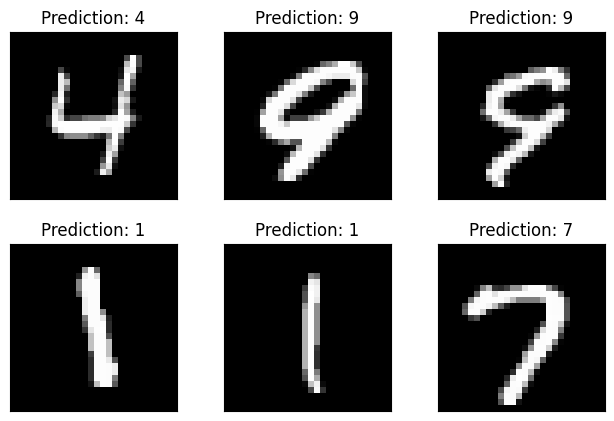

In [22]:
# Run network on data we got before and show predictions
output = model(example_data)

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Prediction: {}".format(
    output.data.max(1, keepdim=True)[1][i].item()))
  plt.xticks([])
  plt.yticks([])
plt.show()

This is the code that does the adversarial attack. It is adapted from [here](https://pytorch.org/tutorials/beginner/fgsm_tutorial.html).   It is an example of the fast gradient sign method (FGSM), which modifies the data by



*   Calculating the derivative $\partial L/\partial \mathbf{x}$ of the loss $L$ with respect to the input data $\mathbf{x}$.
*   Finds the sign of the gradient at each point (making a tensor the same size as $\mathbf{x}$ with a one where it was positive and minus one where it was negative.  
*   Multiplying this vector by $\epsilon$ and adding it back to the original data




In [23]:
# Iterative FGSM attack code.
def fgsm_attack(model, x, y, epsilon, alpha_step=None, num_steps=10):
    # Make a copy of the input image and enable gradient tracking
    x_adv = x.clone().detach()
    x_adv.requires_grad = True

    # If alpha_step is not provided, use a default proportional to epsilon
    if alpha_step is None:
        alpha_step = epsilon / num_steps

    # Define the min/max pixel values for MNIST images after normalization
    # MNIST: mean=0.1307, std=0.3081. Original pixel range [0, 1].
    min_pixel_value = (0 - 0.1307) / 0.3081
    max_pixel_value = (1 - 0.1307) / 0.3081

    # Iteratively perturb the image
    for _ in range(num_steps):
        # Zero out gradients for the input image
        if x_adv.grad is not None:
            x_adv.grad.zero_()

        # Forward pass
        output = model(x_adv)
        loss = F.nll_loss(output, y)

        # Backward pass
        loss.backward()

        # Collect the sign of the gradient
        sign_grad = x_adv.grad.sign()

        # Apply perturbation and detach to prevent gradient accumulation in the graph
        x_adv = x_adv.detach() + alpha_step * sign_grad

        # Clip the adversarial image to stay within epsilon range of original image
        x_adv = torch.max(x_adv, x - epsilon)
        x_adv = torch.min(x_adv, x + epsilon)

        # Clip the adversarial image to stay within valid pixel range [min_val, max_val]
        x_adv = torch.clamp(x_adv, min=min_pixel_value, max=max_pixel_value)

        # Re-enable gradient tracking for the next iteration
        x_adv.requires_grad = True

    return x_adv.detach() # Detach final output to avoid retaining graph

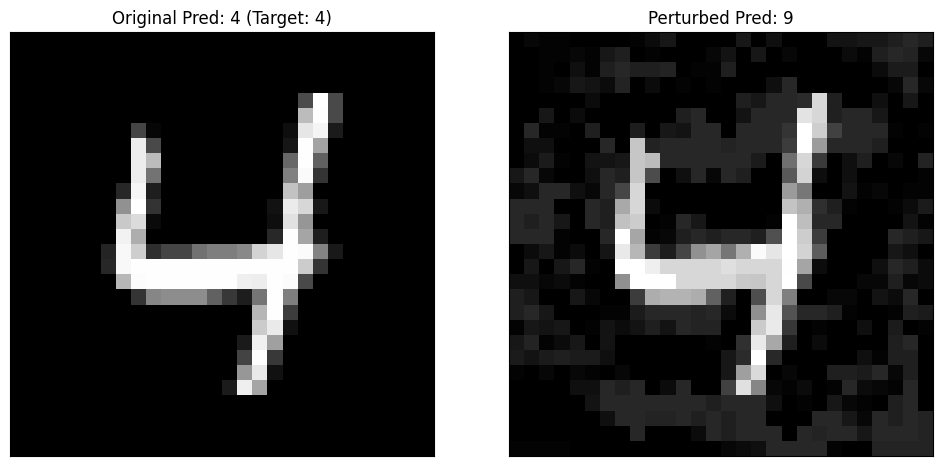

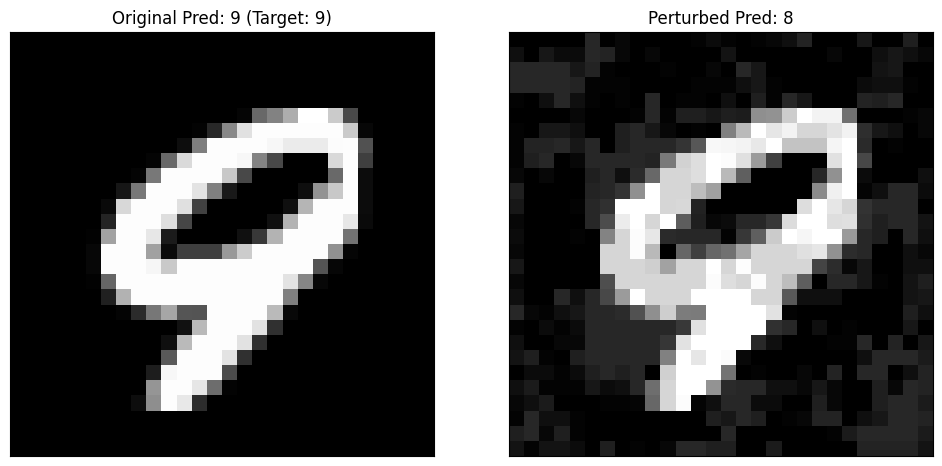

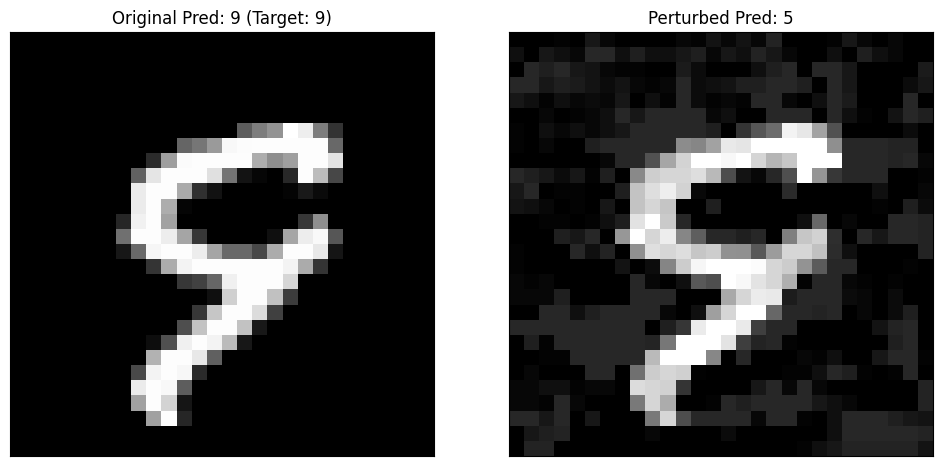

In [24]:
no_examples = 3
epsilon = 0.5 # Total perturbation budget
num_steps = 10 # Number of iterations for I-FGSM
alpha_step = epsilon / num_steps # Step size for each iteration

for i in range(no_examples):
  # Get the i'th data example
  x = example_data[i,:,:,:]
  # Add an extra dimension back to the beginning
  x = x[None, :,:,:]
  # Get the i'th target
  y = torch.ones(1, dtype=torch.long) * example_targets[i]

  # Make a forward pass on the original image to get its prediction
  output = model(x) # Original prediction

  # Call the iterative FGSM Attack
  x_prime = fgsm_attack(model, x, y, epsilon, alpha_step=alpha_step, num_steps=num_steps)

  # Re-classify the perturbed image
  output_prime = model(x_prime)

  x_numpy = x.detach().cpu().numpy() # Convert to numpy for plotting
  x_prime_numpy = x_prime.detach().cpu().numpy() # Convert to numpy for plotting

  fig = plt.figure(figsize=(10, 5)) # Increase figure size for better display
  plt.subplot(1,2,1)
  plt.tight_layout()
  plt.imshow(x_numpy[0][0], cmap='gray', interpolation='none')
  plt.title("Original Pred: {} (Target: {})".format(
    output.data.max(1, keepdim=True)[1][0].item(), y.item()))
  plt.xticks([])
  plt.yticks([])

  plt.subplot(1,2,2)
  plt.tight_layout()
  plt.imshow(x_prime_numpy[0][0], cmap='gray', interpolation='none')
  plt.title("Perturbed Pred: {}".format(
    output_prime.data.max(1, keepdim=True)[1][0].item()))
  plt.xticks([])
  plt.yticks([])

  plt.show()

Although we have only added a small amount of noise, the model is fooled into thinking that these images come from a different class.

TODO -- Modify the attack so that it iteratively perturbs the data. i.e., so we take a small step epsilon, then re-calculate the gradient and take another small step according to the new gradient signs.